# **Inception-ResNet V1 for Facial Recognition**

**Project Goal**: Using the Inception-ResNet V1 model for facial recognition. Specifically, building a model to recognize the face of Mary Kom.

**Objectives**: 

- Detect faces using MTCNN.
- Create face embeddings with inception-ResNet V1.
- Use created embeddings to recognize faces in images.

In [63]:
import sys 
from pathlib import Path

import matplotlib.pyplot as plt
import PIL 
import torch
import torchvision 
from facenet_pytorch import MTCNN, InceptionResnetV1
from PIL import Image
from torch.utils.data import DataLoader
from torchvision import datasets

In [64]:
print("Platform:", sys.platform)
print("Python version:", sys.version)
print("---")
print("PIL version : ", PIL.__version__)
print("torch version : ", torch.__version__)
print("torchvision version : ", torchvision.__version__)

Platform: win32
Python version: 3.12.1 (tags/v3.12.1:2305ca5, Dec  7 2023, 22:03:25) [MSC v.1937 64 bit (AMD64)]
---
PIL version :  10.2.0
torch version :  2.2.2+cpu
torchvision version :  0.17.2+cpu


In [65]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Using {device} device.")

Using cpu device.


**Initializing MTCNN and Inception-ResNet V1**

In [66]:
mtcnn0 = MTCNN(image_size=240,device=device, keep_all=False, min_face_size=40, post_process=False)
print(mtcnn0)

MTCNN(
  (pnet): PNet(
    (conv1): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (prelu1): PReLU(num_parameters=10)
    (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv2): Conv2d(10, 16, kernel_size=(3, 3), stride=(1, 1))
    (prelu2): PReLU(num_parameters=16)
    (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
    (prelu3): PReLU(num_parameters=32)
    (conv4_1): Conv2d(32, 2, kernel_size=(1, 1), stride=(1, 1))
    (softmax4_1): Softmax(dim=1)
    (conv4_2): Conv2d(32, 4, kernel_size=(1, 1), stride=(1, 1))
  )
  (rnet): RNet(
    (conv1): Conv2d(3, 28, kernel_size=(3, 3), stride=(1, 1))
    (prelu1): PReLU(num_parameters=28)
    (pool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv2): Conv2d(28, 48, kernel_size=(3, 3), stride=(1, 1))
    (prelu2): PReLU(num_parameters=48)
    (pool2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (conv3): Conv2d(48, 64,

In [67]:
resnet = InceptionResnetV1(pretrained="vggface2").eval()

In [68]:
print(resnet)

InceptionResnetV1(
  (conv2d_1a): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (conv2d_2a): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (conv2d_2b): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (maxpool_3a): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2d_3b): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
  )
  (conv2d_4a): 

**Preparing Data**

In [69]:
images_folder = Path("data", "images")

print(f"Path to images: {images_folder}")

Path to images: data\images


ImageFolder object:

In [70]:
dataset = datasets.ImageFolder(images_folder)

print(dataset)

Dataset ImageFolder
    Number of datapoints: 10
    Root location: data\images


With the ImageFolder object, each subdirectory of the input path is considered a separate class. The class label is just the name of the subdirectory. 

Printing subdirectories:

In [71]:
for subdirectory in images_folder.iterdir():
    print(subdirectory)

data\images\mary_kom
data\images\ranveer


With a ImageFolder object, the .class_to_idx is a mapping between class label to class integer.

In [72]:
dataset.class_to_idx

{'mary_kom': 0, 'ranveer': 1}

However, we'd like to create the reverse mapping. In other words, integer to class label. Therefore, we create a dictionary that maps integer to class label.

In [73]:
idx_to_class = {i: c for c, i in dataset.class_to_idx.items()}

print(idx_to_class)

{0: 'mary_kom', 1: 'ranveer'}


We now create a DataLoader object with our ImageFolder. These objects are iterables that work well with PyTorch.

In [74]:
def collate_fn(x):
    return x[0]

In [75]:
loader = DataLoader(dataset, collate_fn=collate_fn)

print(loader.dataset)

Dataset ImageFolder
    Number of datapoints: 10
    Root location: data\images


Using a single image:

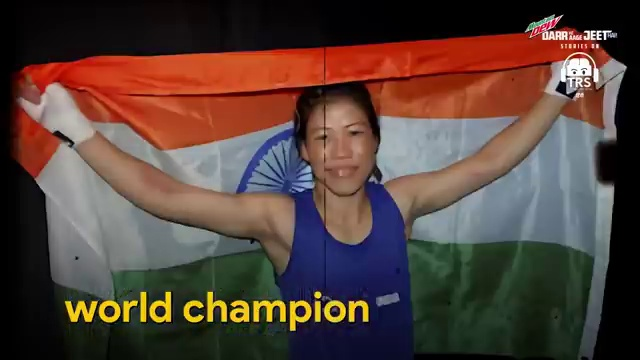

In [76]:
img, _ = iter(loader).__next__()
img

Using mtcnn0 to detect the face and probability:

In [77]:
face, prob = mtcnn0(img, return_prob=True)

print(type(face))
print(f"Probability of detected face: {prob}")

<class 'torch.Tensor'>
Probability of detected face: 0.9999592304229736


The mode is certain that there is a face in the image.

**Running the Inception-ResNet V1 model**

The facial recognition model needs a 4D PyTorch tensor of faces. At the moment, we have just one 3D tensor because we only have one face. Let's see what happens:

In [78]:
try:
    resnet(face)
except ValueError as e:
    print(e)

expected 4D input (got 3D input)


In [79]:
print(face.shape)

torch.Size([3, 240, 240])


Now, let's change the shape of the tensor from [3, 240, 240] to [1, 3, 240, 240].

In [80]:
face_4d = face.unsqueeze(0) # Adding a new dimension at position 0

print(face_4d.shape) 

torch.Size([1, 3, 240, 240])


In [81]:
embedding = resnet(face_4d)

print(f"Shape of face embedding: {embedding.shape}")

Shape of face embedding: torch.Size([1, 512])


The model returns an embedding for the face using 512 dimensions. The embedding is a vector that represents the features the model extracted. Now we are ready to run our model on all the extracted frames. The process will be:

    - Iterate over all images
    - Run the face detection model
    - If the model returns a result and with a probability of at least 90%, add the embeddings to a dictionary that keeps the embeddings for each person separately.

Filter out results in which face is None or where the probability is less than 0.90.

In [82]:
# Dictionary that maps name to list of their embeddings
name_to_embeddings = {name: [] for name in idx_to_class.values()}

for img, idx in loader:
    face, prob = mtcnn0(img, return_prob=True)
    if face is not None and prob >= 0.90:
        emb = resnet(face.unsqueeze(0))
        name_to_embeddings[idx_to_class[idx]].append(emb)

Since we had several images of Mary Kom and Ranveer, we have several face embeddings for each of them. We'll want to create a single face embedding for each person by taking the average across their embeddings. This average face embedding will be our reference for a person, often called a faceprint in analogy with fingerprints.

The first step is to take our list of face embeddings for a person and create one 2D PyTorch tensor. This can be done with torch.stack given our name_to_embedings dictionary.

In [83]:
print(name_to_embeddings.keys())
print(type(name_to_embeddings["mary_kom"]))

dict_keys(['mary_kom', 'ranveer'])
<class 'list'>


Taking the list of embeddings for both Mary and Ranveer and convert each list to a 2D PyTorch tensor by using torch.stack. Then printing the shapes of the two PyTorch tensors resulting from the stacking operation.

In [84]:
embeddings_mary = torch.stack(name_to_embeddings["mary_kom"])
embeddings_ranveer = torch.stack(name_to_embeddings["ranveer"])

embeddings_mary_shape = embeddings_mary.shape
embeddings_ranveer_shape = embeddings_ranveer.shape

print(f"Shape of stack of embeddings for Mary: {embeddings_mary_shape}")
print(f"Shape of stack of embeddings for Ranveer: {embeddings_ranveer_shape}")

Shape of stack of embeddings for Mary: torch.Size([5, 1, 512])
Shape of stack of embeddings for Ranveer: torch.Size([4, 1, 512])


The average of the stacked embeddings along the zero dimension for the embeddings for both Mary Kom and Ranveer.

In [85]:
avg_embedding_mary = torch.mean(embeddings_mary, dim=0)
avg_embedding_ranveer = torch.mean(embeddings_ranveer, dim=0)

print(f"Shape of avg_embedding: {avg_embedding_mary.shape}")
print(f"Shape of avg_embedding: {avg_embedding_ranveer.shape}")

Shape of avg_embedding: torch.Size([1, 512])
Shape of avg_embedding: torch.Size([1, 512])


In [86]:
embeddings_to_save = [
    (avg_embedding_mary, "mary_kom"),
    (avg_embedding_ranveer, "ranveer"),
]


torch.save(embeddings_to_save, "embeddings.pt")


Load embeddings data:

In [87]:
embedding_data = torch.load("embeddings.pt")

names = [name for _, name in embedding_data]
print(f"Loaded the embedding for: {names}")

Loaded the embedding for: ['mary_kom', 'ranveer']


**Inception-ResNet V1 on an Image with One Person**

Creating a path object for the image in data/extracted_frames/frame_100.jpg

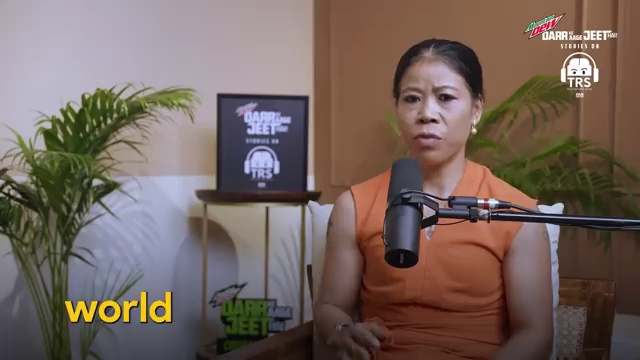

In [88]:
test_img_path = Path("data", "extracted_frames", "frame_100.jpg")

test_img = Image.open(test_img_path)
test_img

Using mtcnn0 to detect all faces:

In [89]:
mtcnn = MTCNN(image_size=240, keep_all=True, min_face_size=40)
print(f"MTCNN image size: {mtcnn.image_size}")
print(f"MTCNN keeping all faces: {mtcnn.keep_all}")

MTCNN image size: 240
MTCNN keeping all faces: True


Running mtcnn on selected frames:

In [90]:
img_cropped_list, prob_list = mtcnn(test_img, return_prob=True)

print(f"Number of detected faces: {len(prob_list)}")
print(f"Probability of detected face: {prob_list[0]}")

Number of detected faces: 1
Probability of detected face: 0.9999531507492065


Running the face recognition model to get the face embedding.

In [91]:
for i, prob in enumerate(prob_list):
    if prob > 0.90:
        emb = resnet(img_cropped_list[i].unsqueeze(0))

With the embedding we created above, emb, we can see how different it's from the average embedding for Mary Kom. Let's compute the distance between emb and the two saved embeddings of Mary and Ranveer.

Using torch.dist to calculate the distance between emb and known_emb

In [92]:
distances = {}

for known_emb, name in embedding_data:
    dist = torch.dist(emb, known_emb)
    distances[name] = dist

closest, min_dist = min(distances.items(), key=lambda x: x[1])
print(f"Closest match: {closest}")
print(f"Calculated distance: {min_dist :.2f}")

Closest match: ranveer
Calculated distance: 1.42


The smallest distance corresponds to Mary Kom. It makes sense the distance is closer for Mary Kom as that's who is in the image.

We can use mtcnn.detect to get the bounding boxes for the faces.

In [93]:
boxes, _ = mtcnn.detect(test_img)
print(f"Shape of boxes tensor: {boxes.shape}")

Shape of boxes tensor: (1, 4)


Drawing a box over a face together with the name of its closest known embedding. We'll use a threshold of 0.8. Any detected face with an embedding that is further than this threshold from a known face will remain unrecognized.

In [94]:
threshold = 0.8

 Recognize Mary Kom's face by drawing a box with her name next to it. Only do so for faces where min_dist is smaller than the threshold. The code below displays the original image and plots the bounding boxes for the detected faces.

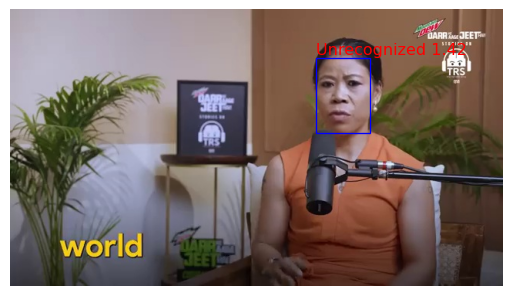

In [95]:
# This sets the image size and draws the original image
width, height = test_img.size
dpi = 96
fig = plt.figure(figsize=(width / dpi, height / dpi), dpi=dpi)
axis = fig.subplots()
axis.imshow(test_img)
plt.axis("off")

for box in boxes:
    rect = plt.Rectangle(
        (box[0], box[1]), box[2] - box[0], box[3] - box[1], fill=False, color="blue"
    )
    axis.add_patch(rect)

    closest, min_dist = min(distances.items(), key=lambda x: x[1])

    # Drawing the box with recognition results

    if min_dist < threshold:
        name = closest
        color = "blue"
    else:
        name = "Unrecognized"
        color = "red"

    plt.text(
        box[0],
        box[1],
        f"{name} {min_dist:.2f}",
        fontsize=12,
        color=color,
        ha="left",
        va="bottom",
    )

plt.axis("off")
plt.show()

**Inception-ResNet V1 on an Image With More Than One Person**